# Cyclotomic Performance Benchmarks

This notebook is a checked-in benchmark report generated from the Rust `examples/perf_bench.rs` executable. The committed outputs make the graphs viewable in GitHub's notebook renderer without rerunning the benchmarks.

The benchmark is intentionally lightweight and comparative. It is useful for spotting representation-level trends, not for publishing stable machine-independent numbers. All charts use a linear throughput axis, so higher is better.

In [1]:
import json
from pathlib import Path

root = Path.cwd()
if not (root / 'benchmarks').exists():
    root = root.parent
records = json.loads((root / 'benchmarks/results/performance.json').read_text())
len(records), records[0]

records: 1074
python: 3.14.4
platform: macOS-26.3-arm64-arm-64bit-Mach-O
generated_at_utc: 2026-04-26T12:29:15+00:00

median throughput by representation and operation:
  dense     add         308.8k ops/s
  dense     mul         15.9k ops/s
  dense     scalar_mul  681.0k ops/s
  sparse    add         838.4k ops/s
  sparse    mul         30.8k ops/s
  sparse    scalar_mul  582.4k ops/s
  structure construct   1.4k ops/s
  structure mul         43.8k ops/s


## Reproduction command

Run this from the repository root to refresh the data and notebook:

```bash
cargo run --release --example perf_bench > benchmarks/results/performance.json
python3 benchmarks/render_notebook.py
```

## Dense vs sparse multiplication, low density

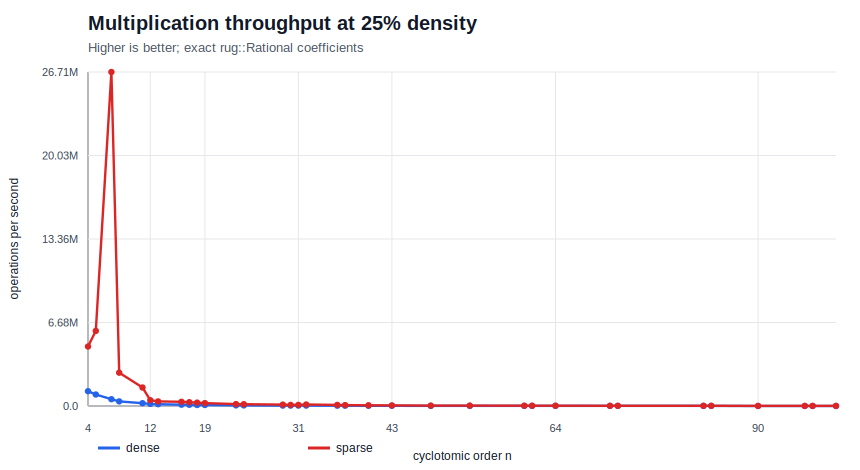

In [2]:
# Rendered from benchmarks/results/performance.json

## Dense vs sparse multiplication, full density

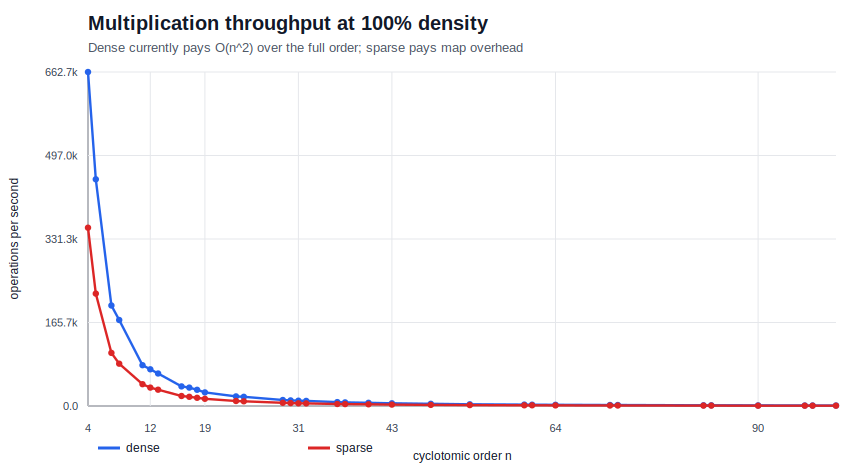

In [3]:
# Rendered from benchmarks/results/performance.json

## Addition by order

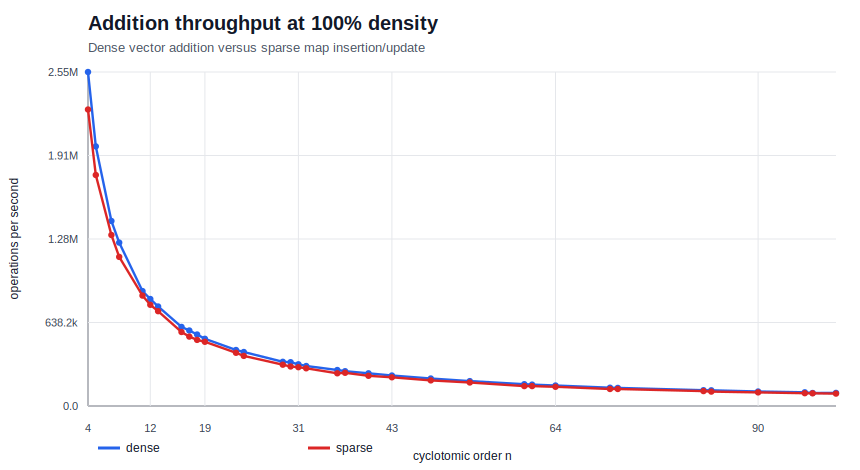

In [4]:
# Rendered from benchmarks/results/performance.json

## Scalar multiplication by order

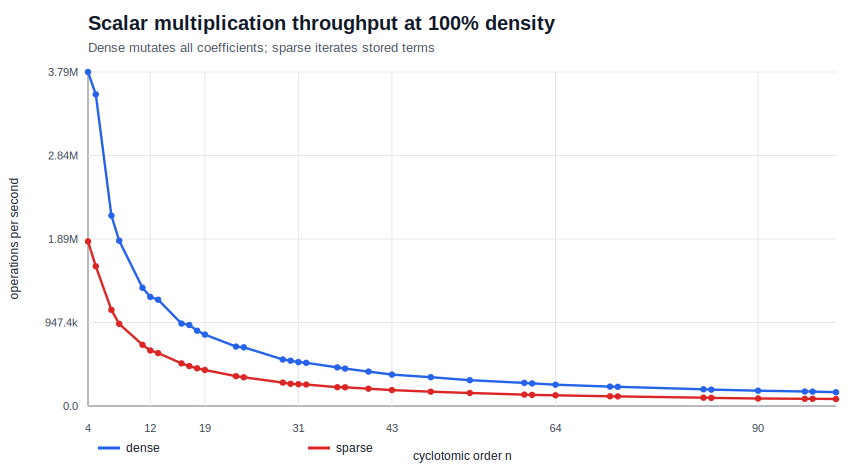

In [5]:
# Rendered from benchmarks/results/performance.json

## Sparse multiplication by density

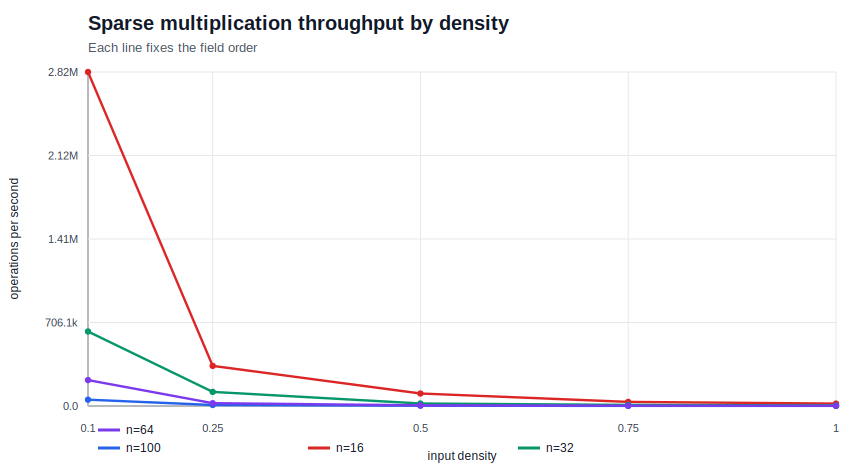

In [6]:
# Rendered from benchmarks/results/performance.json

## Dense multiplication by density

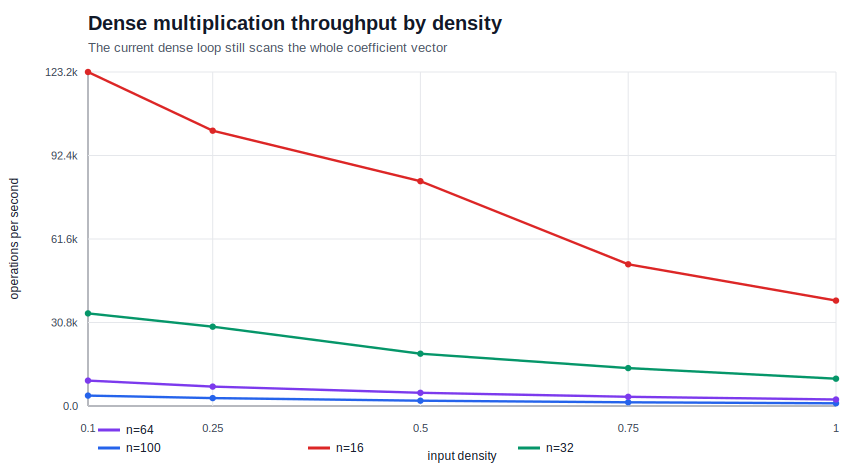

In [7]:
# Rendered from benchmarks/results/performance.json

## Prime-order multiplication

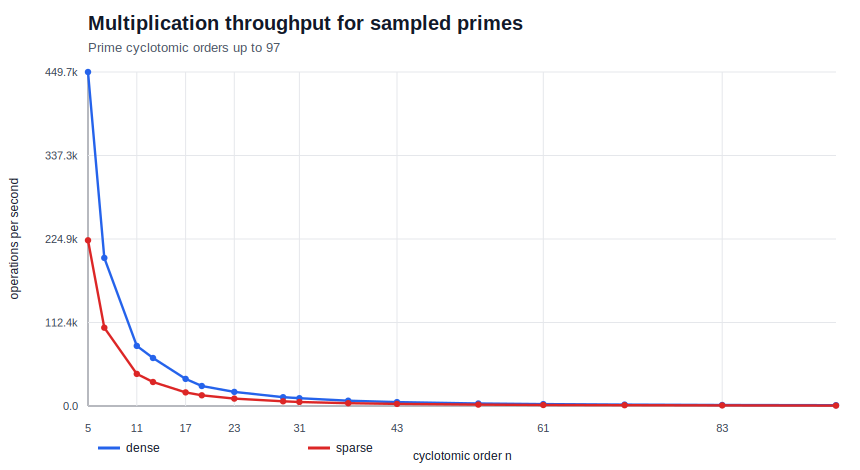

In [8]:
# Rendered from benchmarks/results/performance.json

## Power-of-two multiplication

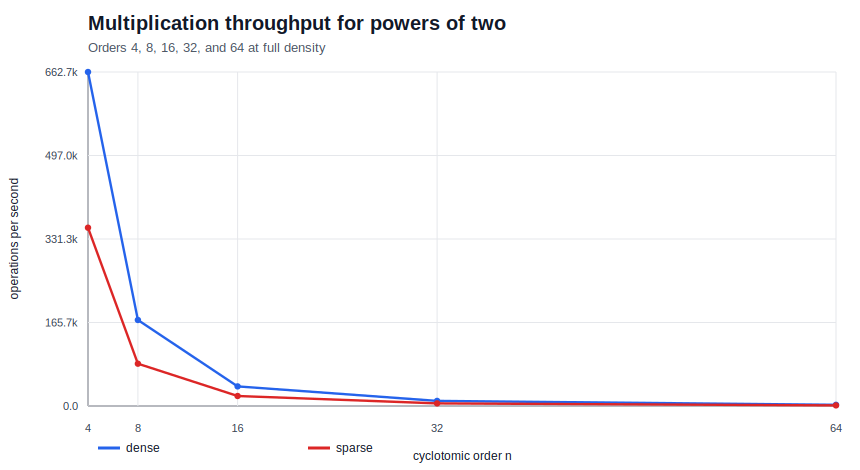

In [9]:
# Rendered from benchmarks/results/performance.json

## Composite-order multiplication

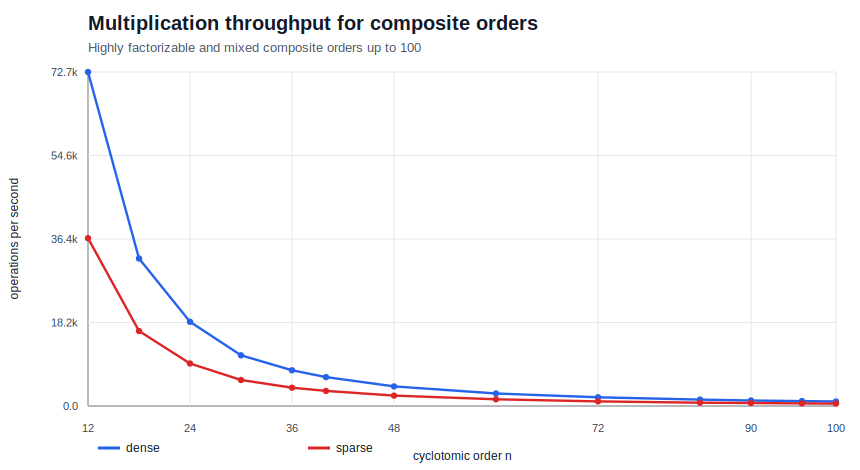

In [10]:
# Rendered from benchmarks/results/performance.json

## Structure constant construction

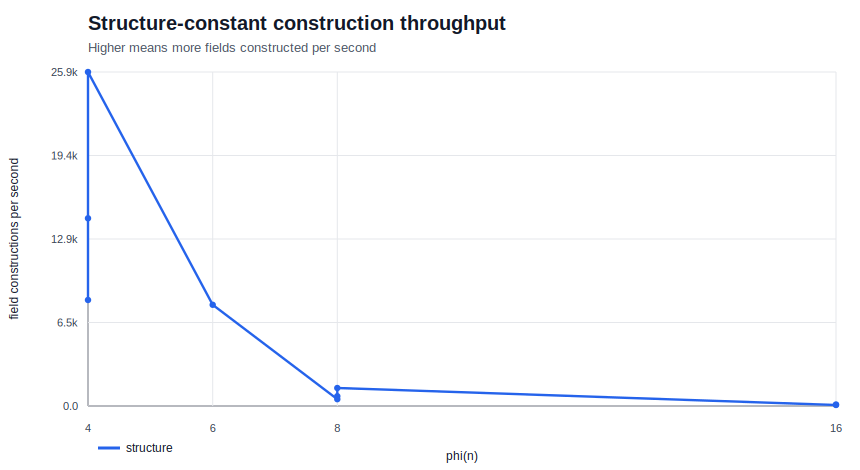

In [11]:
# Rendered from benchmarks/results/performance.json

## Structure multiplication comparison

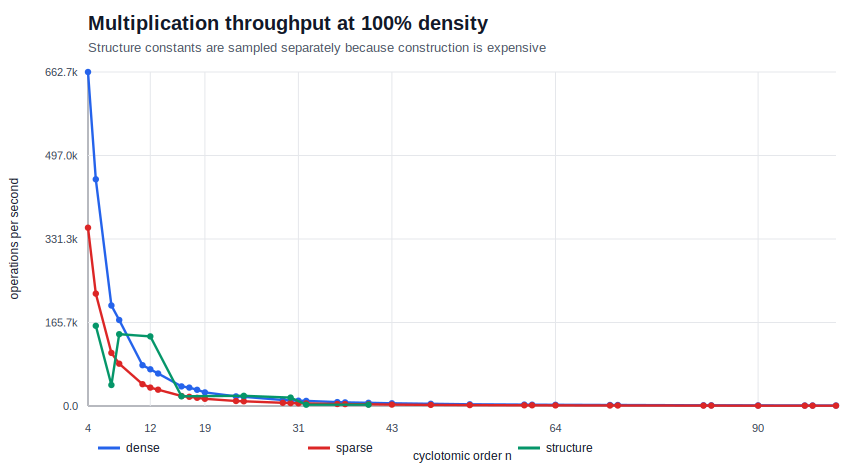

In [12]:
# Rendered from benchmarks/results/performance.json

## Notes

- Dense and sparse operations include clone/setup cost for each timed operation so the benchmark reflects the current mutating API shape.
- Structure-constant construction is separated from multiplication because it is a one-time field setup cost.
- The current results use exact `rug::Rational` coefficients.
- The order sample includes primes, powers of two, and mixed composite orders up to 100.